# detecting.expr1.fsize — plots (tb)

- **Left**: histogram of measured **tb** samples (ns) from all `partes_tb_r*.csv` for each timer (after optional fsize filter).
- **Right**: ECDF with **x = cumulative probability**, **y = time (ns)**. Green: **theoretical tb** from `walk_list_normal.csv` (`tb_ns`); orange: **measured tb** (same samples as the histogram).
- Uses **tb** only; `partes_ta_*` is ignored.
- **Plot trimming**: keep values with `<= quantile(x, QUANTILE_KEEP)` (default `0.995`, i.e. about top `100*(1-QUANTILE_KEEP)%` dropped). Set `1.0` for no trim.
- Run parameters (**np**, **ntests**, **ntiles**, **nwalks**, etc.) are read from `meta.md` / `meta.txt` under `EXP_ROOT` and shown on the figure.


In [1]:
from __future__ import annotations

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Hyperparameters (tweak here)
# =========================

# Root folder of one experiment (change as needed)
EXP_ROOT = Path("/astrum/home/hpchzy/code/data/20260414/cgnr6760pn2/detecting.expr1.fsize/20260414_233633")
WALK_LIST_NAME = "walk_list_normal.csv"  # produced by run_detecting_expr1_fsize.sh

# Multiple fsize dirs: set KiB; None = merge every *_fsize*_walks tree
FSIZE_KIB: int | None = 2048

# Upper-tail trim used for plotting/summary: keep x <= quantile(x, q); 1.0 disables trimming
QUANTILE_KEEP = 0.995

# Histogram binning strategy (left panel)
# - "none": no binning; draw a rug/strip of samples instead of a histogram
# - "fixed_width": fixed-width bins; specify FIXED_BIN_WIDTH_NS; the code will compute N_BINS
# - "auto": matplotlib's automatic binning (bins="auto")
HIST_BINNING: str = "fixed_width"  # "none" | "fixed_width" | "auto"
FIXED_BIN_WIDTH_NS: int = 50  # only used when HIST_BINNING == "fixed_width"

plt.rcParams["figure.dpi"] = 120
# ASCII-only default font for figures (avoid missing-glyph warnings)
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


In [2]:
import re


def list_timers(exp_root: Path) -> list[str]:
    """Top-level experiment subdirs that contain ``{name}_fsize*_walks``."""
    timers: list[str] = []
    for p in sorted(exp_root.iterdir()):
        if not p.is_dir() or p.name.startswith("."):
            continue
        if p.name == "_archive":
            continue
        if list(p.glob(f"{p.name}_fsize*_walks")):
            timers.append(p.name)
    return timers


def walk_dirs_for_timer(exp_root: Path, timer: str, fsize_kib: int | None) -> list[Path]:
    base = exp_root / timer
    roots = sorted(base.glob(f"{timer}_fsize*_walks"))
    if fsize_kib is not None:
        roots = [r for r in roots if f"fsize{fsize_kib}" in r.name]
    out: list[Path] = []
    for wr in roots:
        out.extend(sorted(wr.glob("w*")))
    return [w for w in out if w.is_dir()]


def load_theory_tb_ns(exp_root: Path) -> np.ndarray:
    p = exp_root / WALK_LIST_NAME
    if not p.is_file():
        raise FileNotFoundError(p)
    df = pd.read_csv(p)
    return df["tb_ns"].to_numpy(dtype=np.int64)


def load_tb_samples(walk_dirs: list[Path]) -> np.ndarray:
    blocks: list[np.ndarray] = []
    for wd in walk_dirs:
        for f in sorted(wd.glob("partes_tb_r*.csv")):
            arr = np.loadtxt(f, dtype=np.int64)
            if arr.ndim == 0:
                arr = np.array([arr], dtype=np.int64)
            blocks.append(arr.ravel())
    if not blocks:
        return np.array([], dtype=np.int64)
    return np.concatenate(blocks, axis=0)


def ecdf_p_vs_t(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """ECDF: x = cumulative probability p, y = sorted time (ns)."""
    if x.size == 0:
        return np.array([]), np.array([])
    t = np.sort(x.astype(float))
    n = t.size
    p = (np.arange(1, n + 1) - 0.5) / n
    return p, t


def trim_upper_tail(x: np.ndarray, q_keep: float) -> np.ndarray:
    """Upper-tail trim: keep values with x <= quantile(x, q_keep). q_keep >= 1.0 returns x unchanged."""
    if x.size == 0 or q_keep >= 1.0:
        return x
    cap = float(np.quantile(x, q_keep))
    out = x[x <= cap]
    return out.astype(np.int64, copy=False) if out.dtype == np.int64 or x.dtype == np.int64 else out


def load_experiment_meta(exp_root: Path) -> dict[str, str]:
    """Load ``key=value`` lines from meta.txt and table rows ``| key | `value` |`` from meta.md."""
    out: dict[str, str] = {}
    p_txt = exp_root / "meta.txt"
    if p_txt.is_file():
        for line in p_txt.read_text().splitlines():
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            k, _, v = line.partition("=")
            out[k.strip()] = v.strip()
    p_md = exp_root / "meta.md"
    if p_md.is_file():
        for m in re.finditer(
            r"^\|\s*([^|\n]+?)\s*\|\s*`([^`]*)`\s*\|",
            p_md.read_text(),
            re.MULTILINE,
        ):
            k = m.group(1).strip()
            if not k or k in ("Key", "Parameter", "Item") or k.startswith("---"):
                continue
            out[k] = m.group(2).strip()
    return out


def format_experiment_meta_line(meta: dict[str, str]) -> str:
    """Compact English annotation of main knobs (see run_detecting_expr1_fsize.sh / meta.md)."""
    parts: list[str] = []
    order: list[tuple[str, str]] = [
        ("expr_name", "expr"),
        ("timestamp", "ts"),
        ("np", "np"),
        ("ntests", "ntests"),
        ("ntiles", "ntiles"),
        ("cut-p", "cut_p"),
        ("gauge", "gauge"),
        ("fkern", "fkern"),
        ("fsize_list (KiB)", "fsize_KiB"),
        ("rkern", "rkern"),
        ("rsize (KiB)", "rsize_KiB"),
        ("nwalks", "nwalks"),
        ("mu_ns", "mu_ns"),
        ("sigma_rel", "sigma_rel"),
    ]
    for md_key, label in order:
        v = meta.get(md_key)
        if v is not None and str(v).strip() != "":
            parts.append(f"{label}={v}")
    return "  |  ".join(parts)


def hist_edges_fixed_width(x: np.ndarray, bin_width_ns: int) -> np.ndarray:
    """Compute fixed-width histogram edges. Returns (n_bins+1) edges."""
    if x.size == 0:
        return np.array([0.0, float(bin_width_ns)])
    if bin_width_ns <= 0:
        raise ValueError("FIXED_BIN_WIDTH_NS must be > 0")
    x_min = float(np.min(x))
    x_max = float(np.max(x))
    if x_max == x_min:
        return np.array([x_min - 0.5, x_max + 0.5])

    start = np.floor(x_min / bin_width_ns) * bin_width_ns
    stop = np.ceil(x_max / bin_width_ns) * bin_width_ns
    n_bins = int(max(1, round((stop - start) / bin_width_ns)))
    edges = start + np.arange(n_bins + 1, dtype=float) * float(bin_width_ns)
    return edges


def plot_left_panel(ax, x: np.ndarray) -> dict[str, float | int | str]:
    """Draw the left panel and return info about the binning used."""
    info: dict[str, float | int | str] = {"mode": HIST_BINNING}

    if HIST_BINNING == "none":
        # Rug plot (no binning)
        if x.size:
            ax.plot(
                x.astype(float),
                np.zeros_like(x, dtype=float),
                "|",
                color="steelblue",
                alpha=0.25,
                markersize=6,
            )
        ax.set_ylabel("")
        ax.set_yticks([])
        ax.set_xlabel("Time (ns)")
        info["n"] = int(x.size)
        return info

    if HIST_BINNING == "fixed_width":
        edges = hist_edges_fixed_width(x.astype(float), int(FIXED_BIN_WIDTH_NS))
        n_bins = int(edges.size - 1)
        ax.hist(x, bins=edges, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_xlabel("Time (ns)")
        ax.set_ylabel("Count")
        info["bin_width_ns"] = int(FIXED_BIN_WIDTH_NS)
        info["n_bins"] = n_bins
        return info

    if HIST_BINNING == "auto":
        ax.hist(x, bins="auto", color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_xlabel("Time (ns)")
        ax.set_ylabel("Count")
        return info

    raise ValueError(f"Unknown HIST_BINNING: {HIST_BINNING!r}")


In [3]:
# =========================
# Data loading (run once)
# =========================

exp_root = Path(EXP_ROOT).resolve()
exp_meta = load_experiment_meta(exp_root)

theory_tb_ns = load_theory_tb_ns(exp_root)
timers = list_timers(exp_root)

# Cache raw measured samples by timer so you can tweak plotting without re-reading CSVs.
measured_tb_by_timer: dict[str, np.ndarray] = {}

table_rows: list[dict[str, object]] = []
for tm in timers:
    walks = walk_dirs_for_timer(exp_root, tm, FSIZE_KIB)
    measured = load_tb_samples(walks)
    measured_tb_by_timer[tm] = measured

    n_csv = sum(len(list(w.glob("partes_tb_r*.csv"))) for w in walks)
    table_rows.append(
        {
            "timer": tm,
            "n_walks": len(walks),
            "n_partes_tb_csv": n_csv,
            "n_samples": int(measured.size),
            "n_after_trim": int(trim_upper_tail(measured, QUANTILE_KEEP).size),
        }
    )

summary = pd.DataFrame(table_rows)

theory_trim = trim_upper_tail(theory_tb_ns, QUANTILE_KEEP)
print("EXP_ROOT:", exp_root)
print("Meta (summary):", format_experiment_meta_line(exp_meta))
print("Theory walks (tb_ns):", theory_tb_ns.size, "| min/max:", int(theory_tb_ns.min()), int(theory_tb_ns.max()))
print("After trim (theory):", theory_trim.size, "| QUANTILE_KEEP=", QUANTILE_KEEP)
print("FSIZE_KIB filter:", FSIZE_KIB)
print()
print(summary.to_string(index=False))


EXP_ROOT: /astrum/home/hpchzy/code/data/20260414/cgnr6760pn2/detecting.expr1.fsize/20260414_233633
Meta (summary): expr=detecting.expr1.fsize  |  ts=20260414_233633  |  np=64  |  ntests=100  |  ntiles=100  |  cut_p=0.995  |  gauge=sub_scalar  |  fkern=copy  |  fsize_KiB=2048  |  rkern=none  |  rsize_KiB=0  |  nwalks=100  |  mu_ns=10000.0  |  sigma_rel=0.015
Theory walks (tb_ns): 100 | min/max: 9601 10301
After trim (theory): 99 | QUANTILE_KEEP= 0.995
FSIZE_KIB filter: 2048

        timer  n_walks  n_partes_tb_csv  n_samples  n_after_trim
clock_gettime      100             6400     640000        636803
       likwid      100             6400     640000        636800
    mpi_wtime      100             6400     640000        636803
         papi      100             6400     640000        636801
       papix6      100             6400     640000        636801
     tsc_asym      100             6400     640000        636801


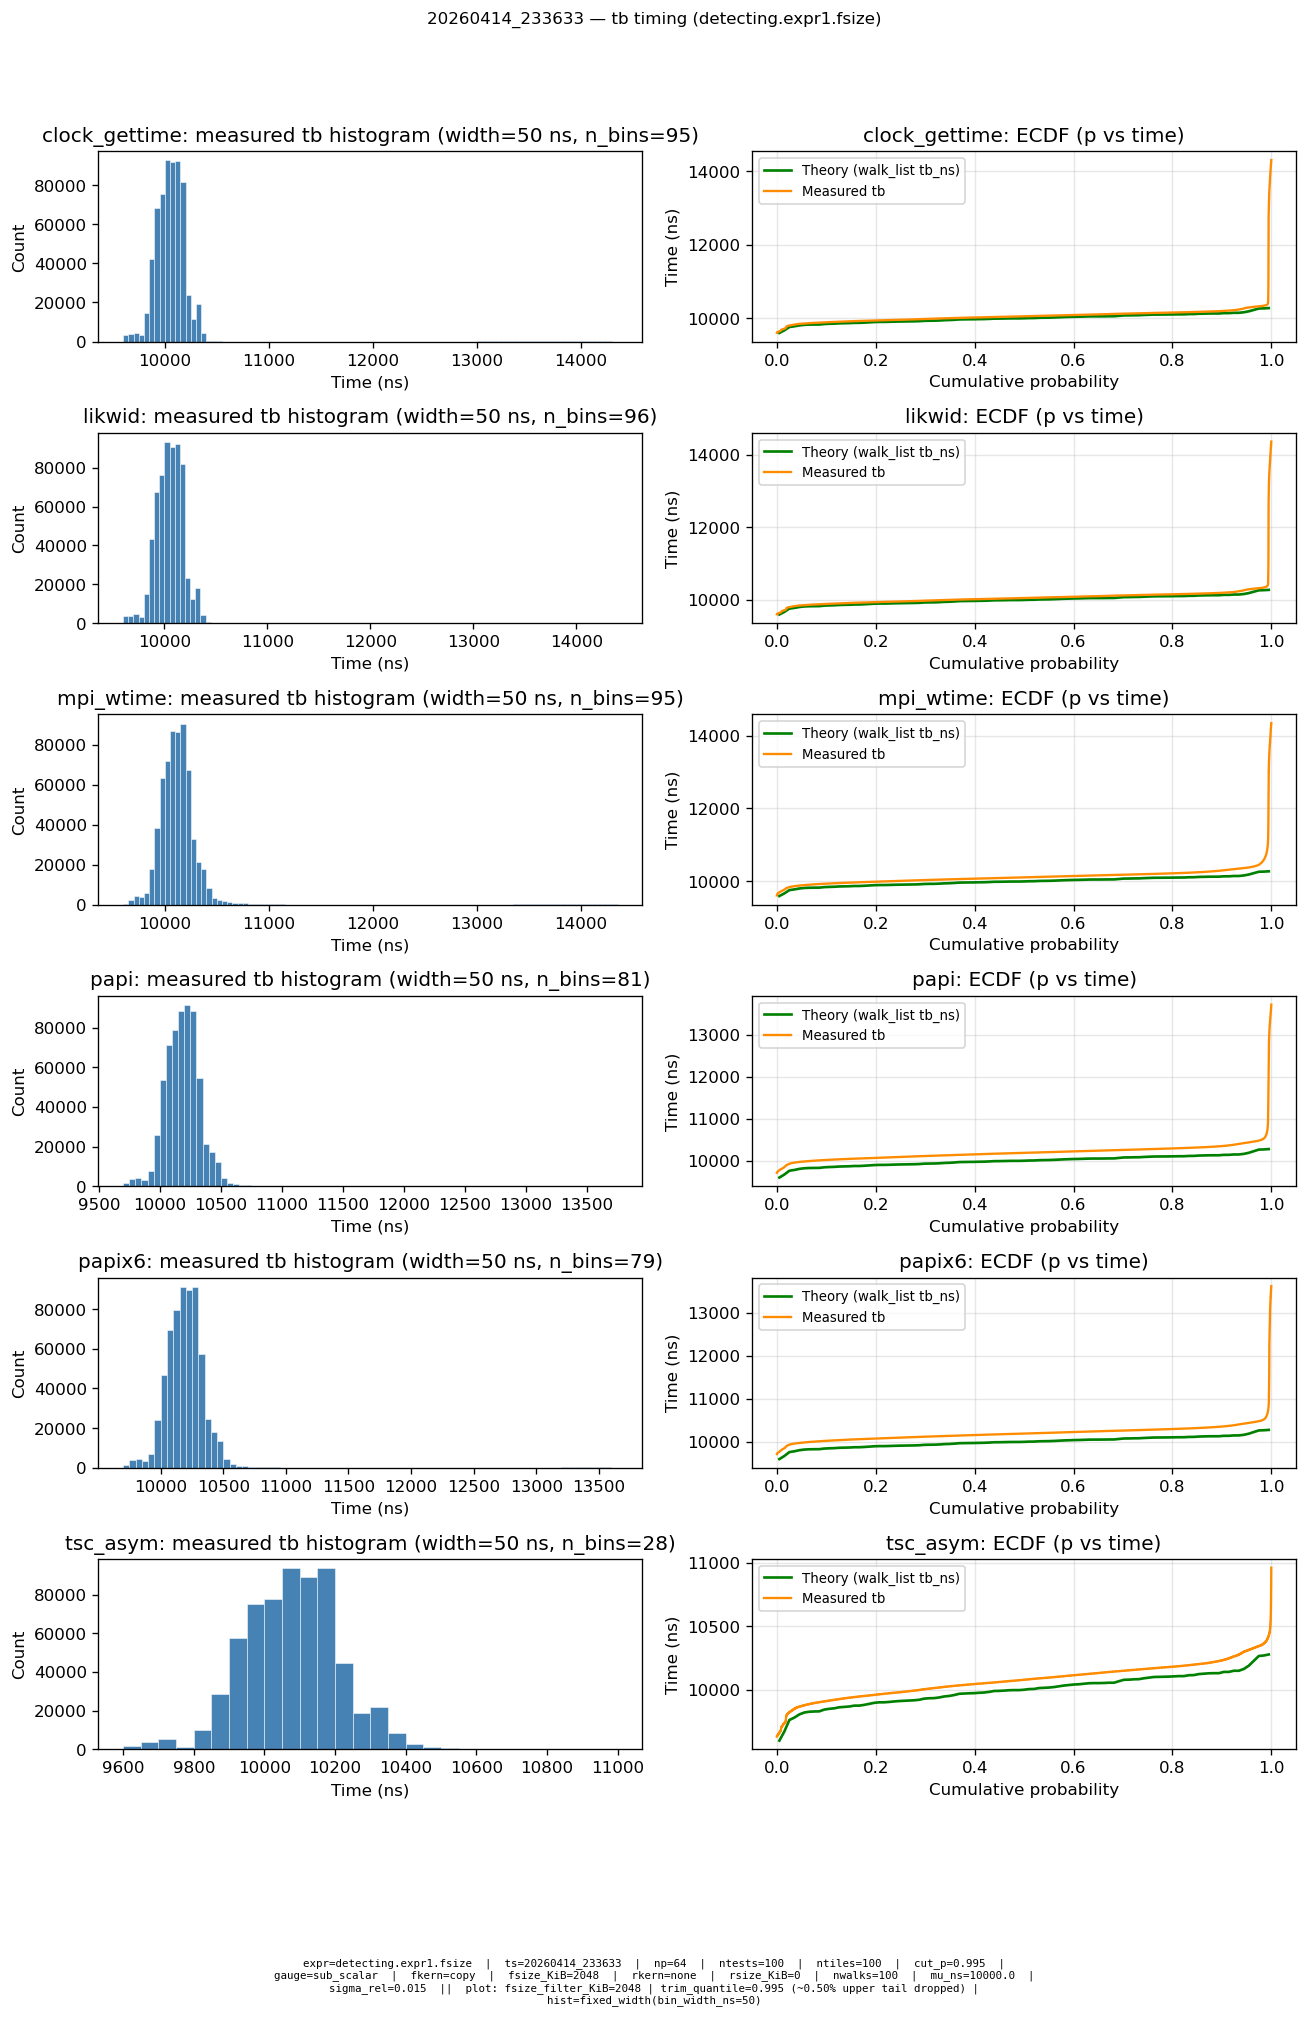

In [4]:
# =========================
# Data operations + plotting controls
# =========================

if not timers:
    raise RuntimeError("No timer directories found under EXP_ROOT")

n = len(timers)
fig, axes = plt.subplots(n, 2, figsize=(11, 2.9 * n), squeeze=False)

theory_plot = trim_upper_tail(theory_tb_ns, QUANTILE_KEEP)
p_th, t_th = ecdf_p_vs_t(theory_plot)

for i, tm in enumerate(timers):
    ax_left, ax_cdf = axes[i, 0], axes[i, 1]

    measured_raw = measured_tb_by_timer.get(tm, np.array([], dtype=np.int64))
    measured_plot = trim_upper_tail(measured_raw, QUANTILE_KEEP)

    left_info = plot_left_panel(ax_left, measured_plot)
    if HIST_BINNING == "none":
        ax_left.set_title(f"{tm}: measured tb (no binning)")
    elif HIST_BINNING == "fixed_width":
        ax_left.set_title(
            f"{tm}: measured tb histogram (width={FIXED_BIN_WIDTH_NS} ns, n_bins={left_info.get('n_bins','?')})"
        )
    else:
        ax_left.set_title(f"{tm}: measured tb histogram")

    p_m, t_m = ecdf_p_vs_t(measured_plot)
    ax_cdf.plot(p_th, t_th, label="Theory (walk_list tb_ns)", color="green", linewidth=1.6)
    ax_cdf.plot(p_m, t_m, label="Measured tb", color="darkorange", linewidth=1.4)
    ax_cdf.set_xlabel("Cumulative probability")
    ax_cdf.set_ylabel("Time (ns)")
    ax_cdf.set_title(f"{tm}: ECDF (p vs time)")
    ax_cdf.legend(loc="upper left", fontsize=8)
    ax_cdf.grid(True, alpha=0.3)

meta_line = format_experiment_meta_line(exp_meta)
plot_line = (
    f"plot: fsize_filter_KiB={FSIZE_KIB} | trim_quantile={QUANTILE_KEEP} "
    f"(~{100 * (1 - QUANTILE_KEEP):.2f}% upper tail dropped)"
)
if HIST_BINNING == "fixed_width":
    plot_line += f" | hist=fixed_width(bin_width_ns={FIXED_BIN_WIDTH_NS})"
elif HIST_BINNING == "none":
    plot_line += " | hist=none(rug)"
else:
    plot_line += " | hist=auto"

footer = textwrap.fill(f"{meta_line}  ||  {plot_line}", width=118)
n_footer_lines = footer.count("\n") + 1
bottom_frac = min(0.06 + 0.019 * n_footer_lines, 0.42)

fig.suptitle(f"{exp_root.name} — tb timing (detecting.expr1.fsize)", fontsize=10, y=1.0)
fig.tight_layout(rect=[0, bottom_frac, 1, 0.97])
fig.text(
    0.5,
    bottom_frac * 0.5,
    footer,
    ha="center",
    va="top",
    fontsize=6.5,
    family="monospace",
    transform=fig.transFigure,
)
plt.show()
